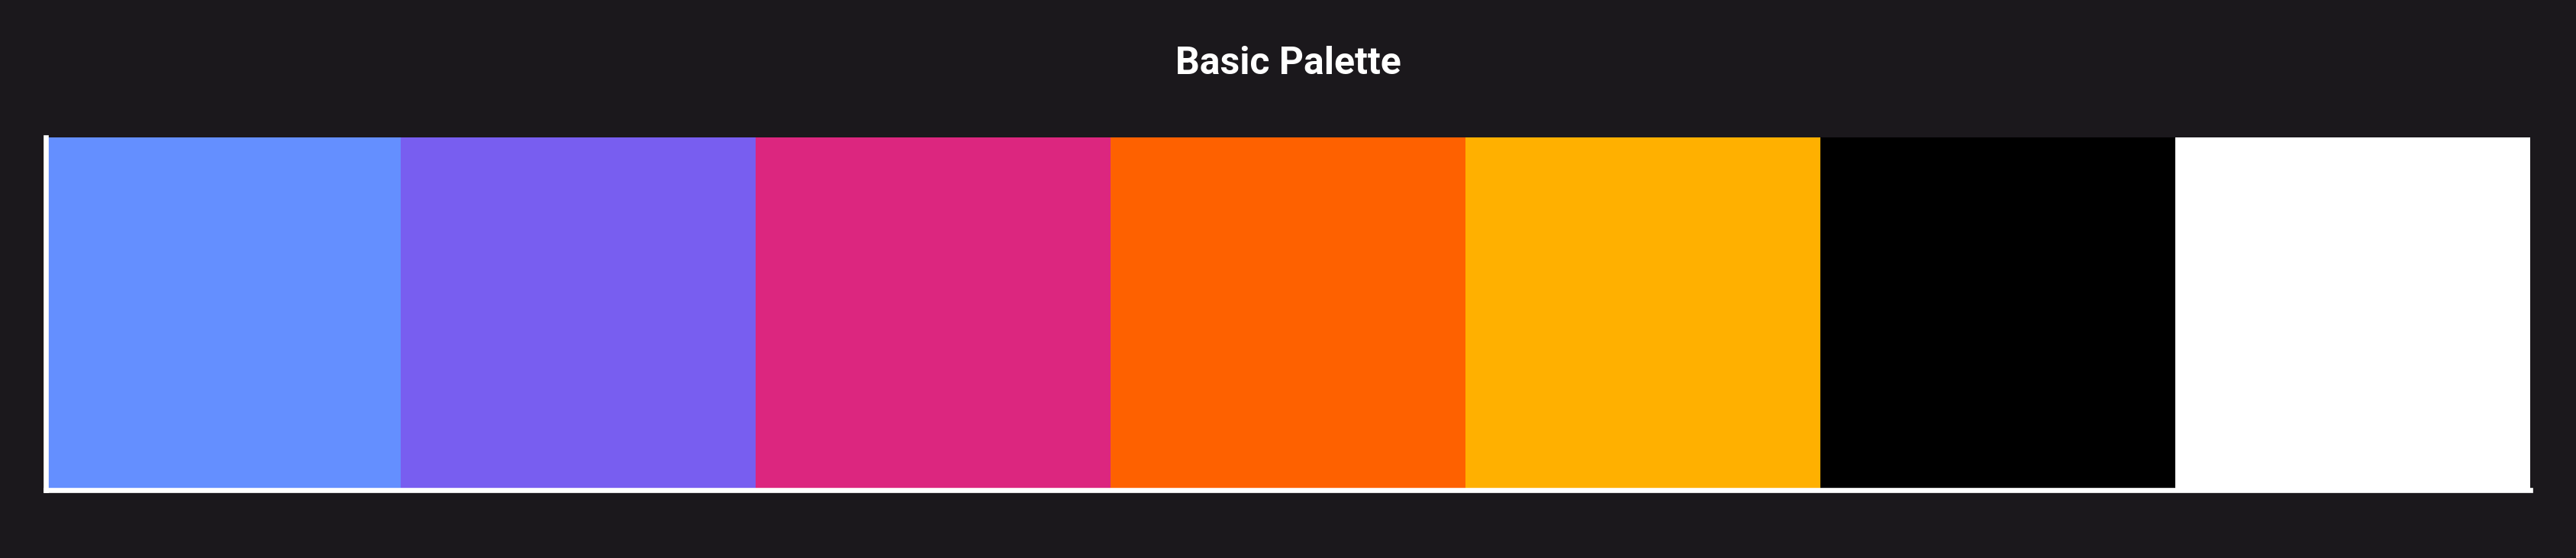

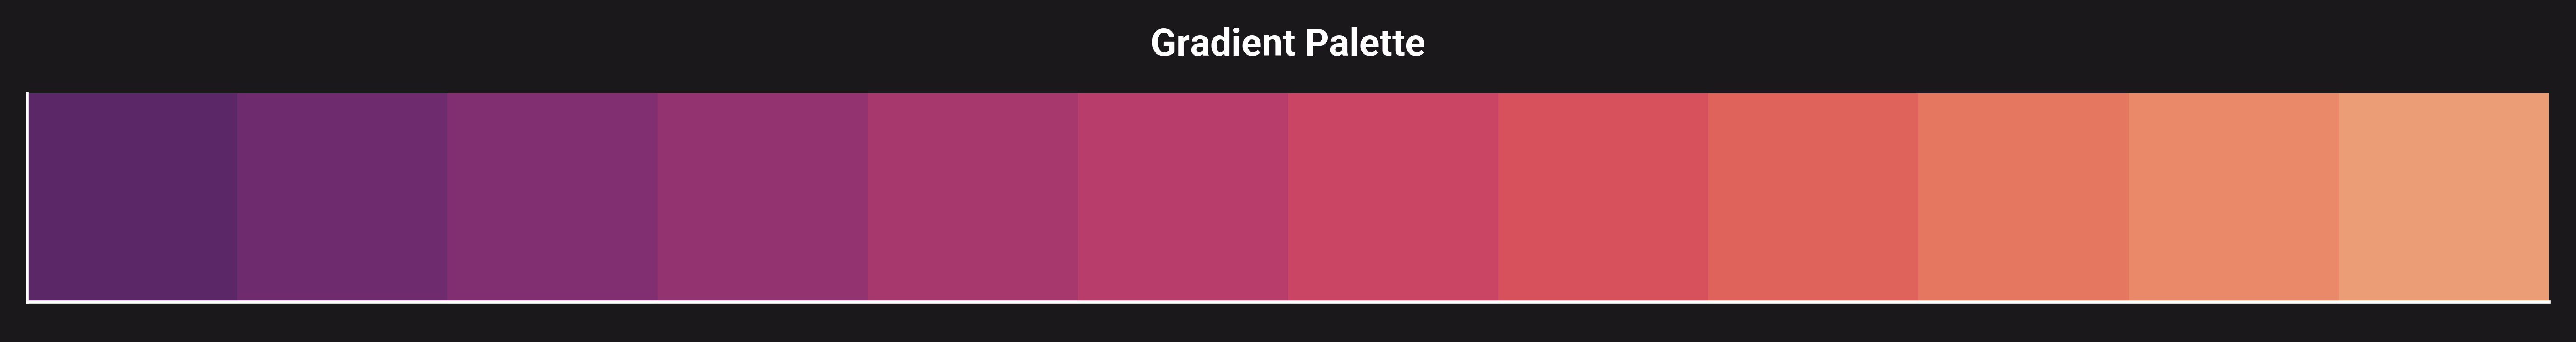

In [47]:
from data_preprocessing import ph_restos
import pandas as pd
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns

# @title Get fonts
fm.fontManager.addfont('Roboto/static/Roboto-Light.ttf')
fm.fontManager.addfont('Roboto/static/Roboto-Regular.ttf')
fm.fontManager.addfont('Roboto/static/Roboto-Medium.ttf')
fm.fontManager.addfont('Roboto/static/Roboto-Bold.ttf')

colors = ["#648FFF", "#785EF0", "#DC267F", "#FE6100", "#FFB000", "#000000", "#FFFFFF"]
colors_grad = sns.color_palette('flare_r',  12)
colors_heat1 = sns.color_palette('flare_r', as_cmap=True)
colors_heat2 = sns.diverging_palette(315, 261, s=74, l=50, center='dark', as_cmap=True)

color_bg = "#1B181C"
color_text = "#FFFFFF"

sns.palplot(colors)
plt.gca().set_title('Basic Palette', fontsize=6, pad=10)

sns.palplot(colors_grad)
plt.gca().set_title('Gradient Palette', fontsize=10, pad=10)

plt.show()

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams["figure.figsize"] = 16,8

# Text
mpl.rcParams['font.family'] = 'Roboto'

# Title
mpl.rcParams['figure.titlesize'] = 32
mpl.rcParams['axes.titlesize'] = 32
mpl.rcParams['axes.titleweight'] = 'bold'

# Labels
mpl.rcParams['axes.labelsize'] = 22
mpl.rcParams['xtick.labelsize'] = 22
mpl.rcParams['ytick.labelsize'] = 22

# Spacing
mpl.rcParams['axes.titlepad'] = 72
mpl.rcParams['axes.labelpad'] = 10
mpl.rcParams['xtick.major.pad'] = 10
mpl.rcParams['ytick.major.pad'] = 10
mpl.rcParams['xtick.major.width'] = 0
mpl.rcParams['xtick.minor.width'] = 0
mpl.rcParams['ytick.major.width'] = 0
mpl.rcParams['ytick.minor.width'] = 0

# Spines and grids
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.grid'] = False

# Legends
mpl.rcParams['legend.title_fontsize'] = 18
mpl.rcParams['legend.fontsize'] = 18
mpl.rcParams['legend.frameon'] = False

# Bars
plt.rcParams['patch.linewidth'] = 0
plt.rcParams['patch.edgecolor'] = 'none'

# Colors
mpl.rcParams["figure.facecolor"] = color_bg
mpl.rcParams["axes.facecolor"] = color_bg
mpl.rcParams["savefig.facecolor"] = color_bg

# Text colors
mpl.rcParams['text.color'] = color_text
mpl.rcParams['axes.labelcolor'] = color_text
mpl.rcParams['xtick.color'] = color_text
mpl.rcParams['ytick.color'] = color_text

# Line colors
mpl.rcParams['axes.edgecolor'] = color_text

# of unique food types in HUC: 67
# of unique food types in rural: 59


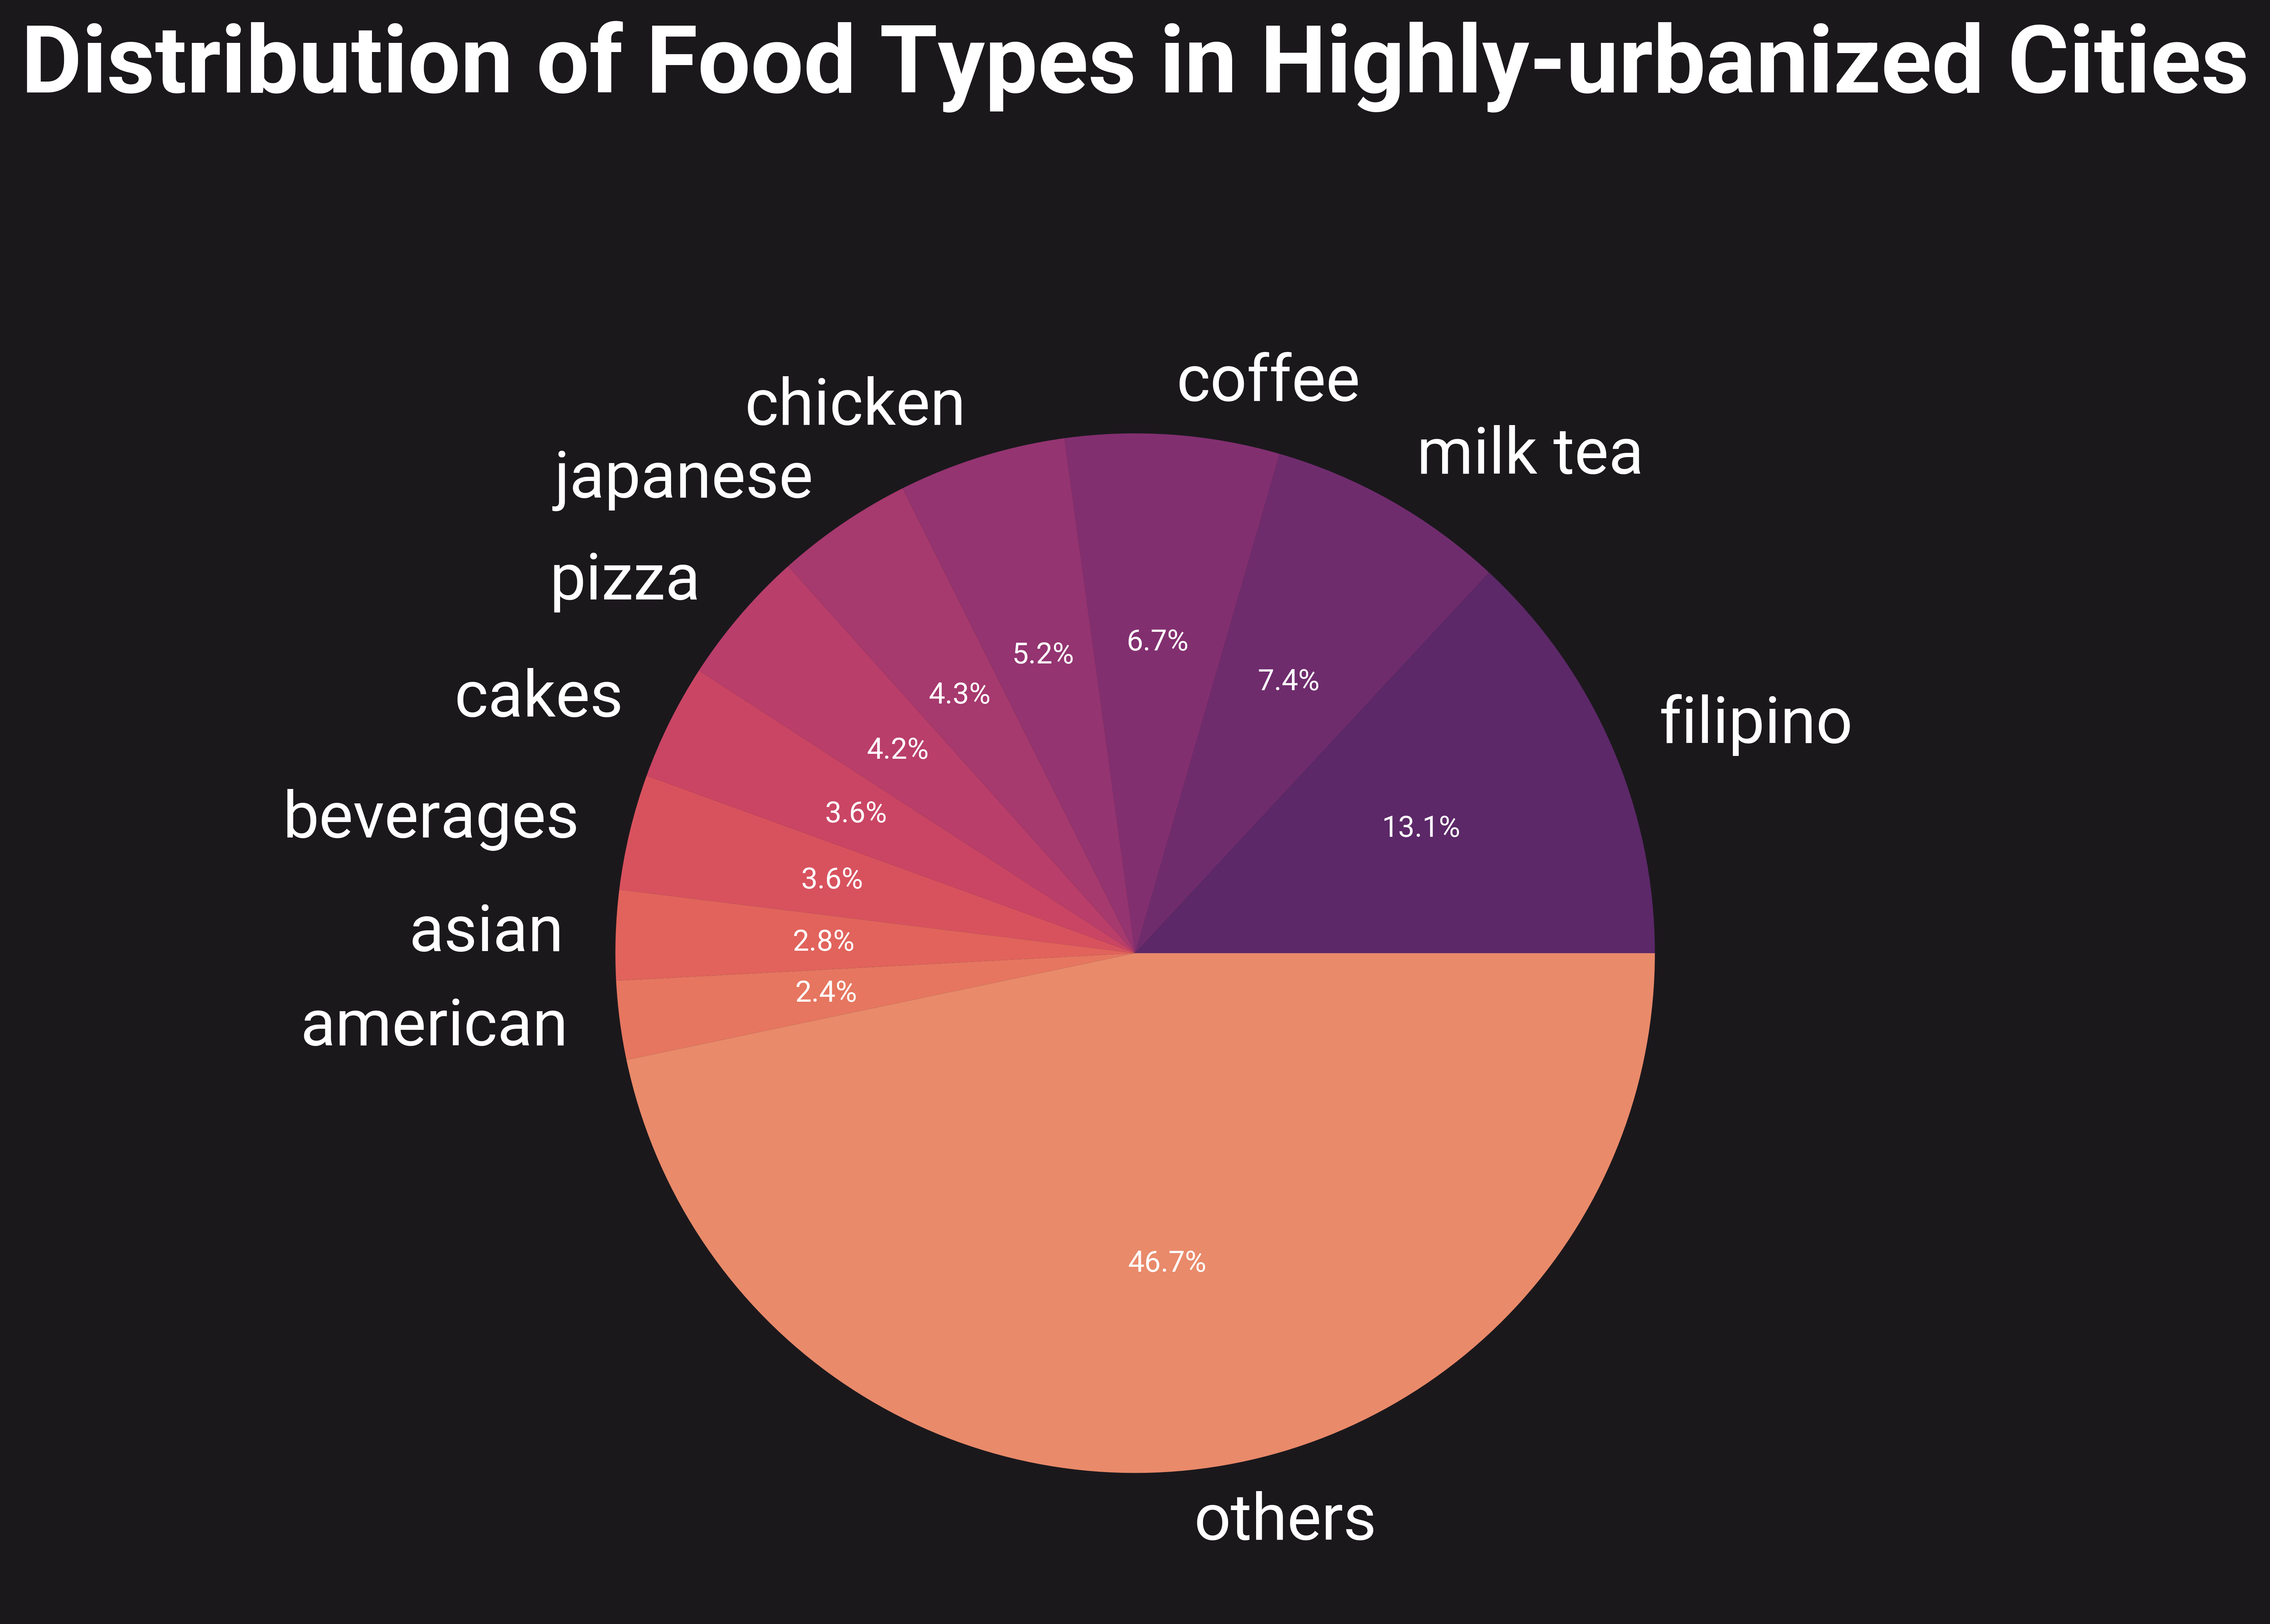

In [68]:
highly_urbanized_cities = [
    'cebu city',
    'davao city davao del sur',
    'lapu-lapu city cebu',
    'makati city',
    'mandaluyong city',
    'manila',
    'marikina',
    'muntinlupa city',
    'pasay city',
    'pasig city',
    'quezon city',
    'san juan',
    'taguig city'
]

component_cities = [
    'dagupan pangasinan',
    'koronadal south cotabato',
    'malolos bulacan',
    'ormoc leyte',
    'valencia bukidnon'
]

def label_city(vector):
    if vector["City"] in highly_urbanized_cities:
        return 1
    else:
        return 0

ph_restos["HighlyUrbanized"] = ph_restos.apply(label_city, axis=1)

highly_urbanized = ph_restos[ph_restos['HighlyUrbanized']==1]
component = ph_restos[ph_restos['HighlyUrbanized']==0]

highly_urbanized_counts = highly_urbanized["FoodType"].value_counts()
component_counts = component["FoodType"].value_counts()
print("# of unique food types in HUC:",len(highly_urbanized_counts))
print("# of unique food types in rural:",len(component_counts))

# Keep only the Top 9 and aggregate the rest in an "Others" category
n = 0
num_counts = []
label_counts = []
others_counts = 0

for index, value in highly_urbanized_counts.items():
    if n<10:
        num_counts.append(value)
        label_counts.append(index)
    else:
        others_counts += value
    n+=1
num_counts.append(others_counts)
label_counts.append("others")

highly_urbanized_top10 = pd.Series(num_counts, label_counts)
plt.pie(highly_urbanized_top10, colors=colors_grad, labels=label_counts, autopct='%1.1f%%')
plt.title(label="Distribution of Food Types in Highly-urbanized Cities")
plt.show()

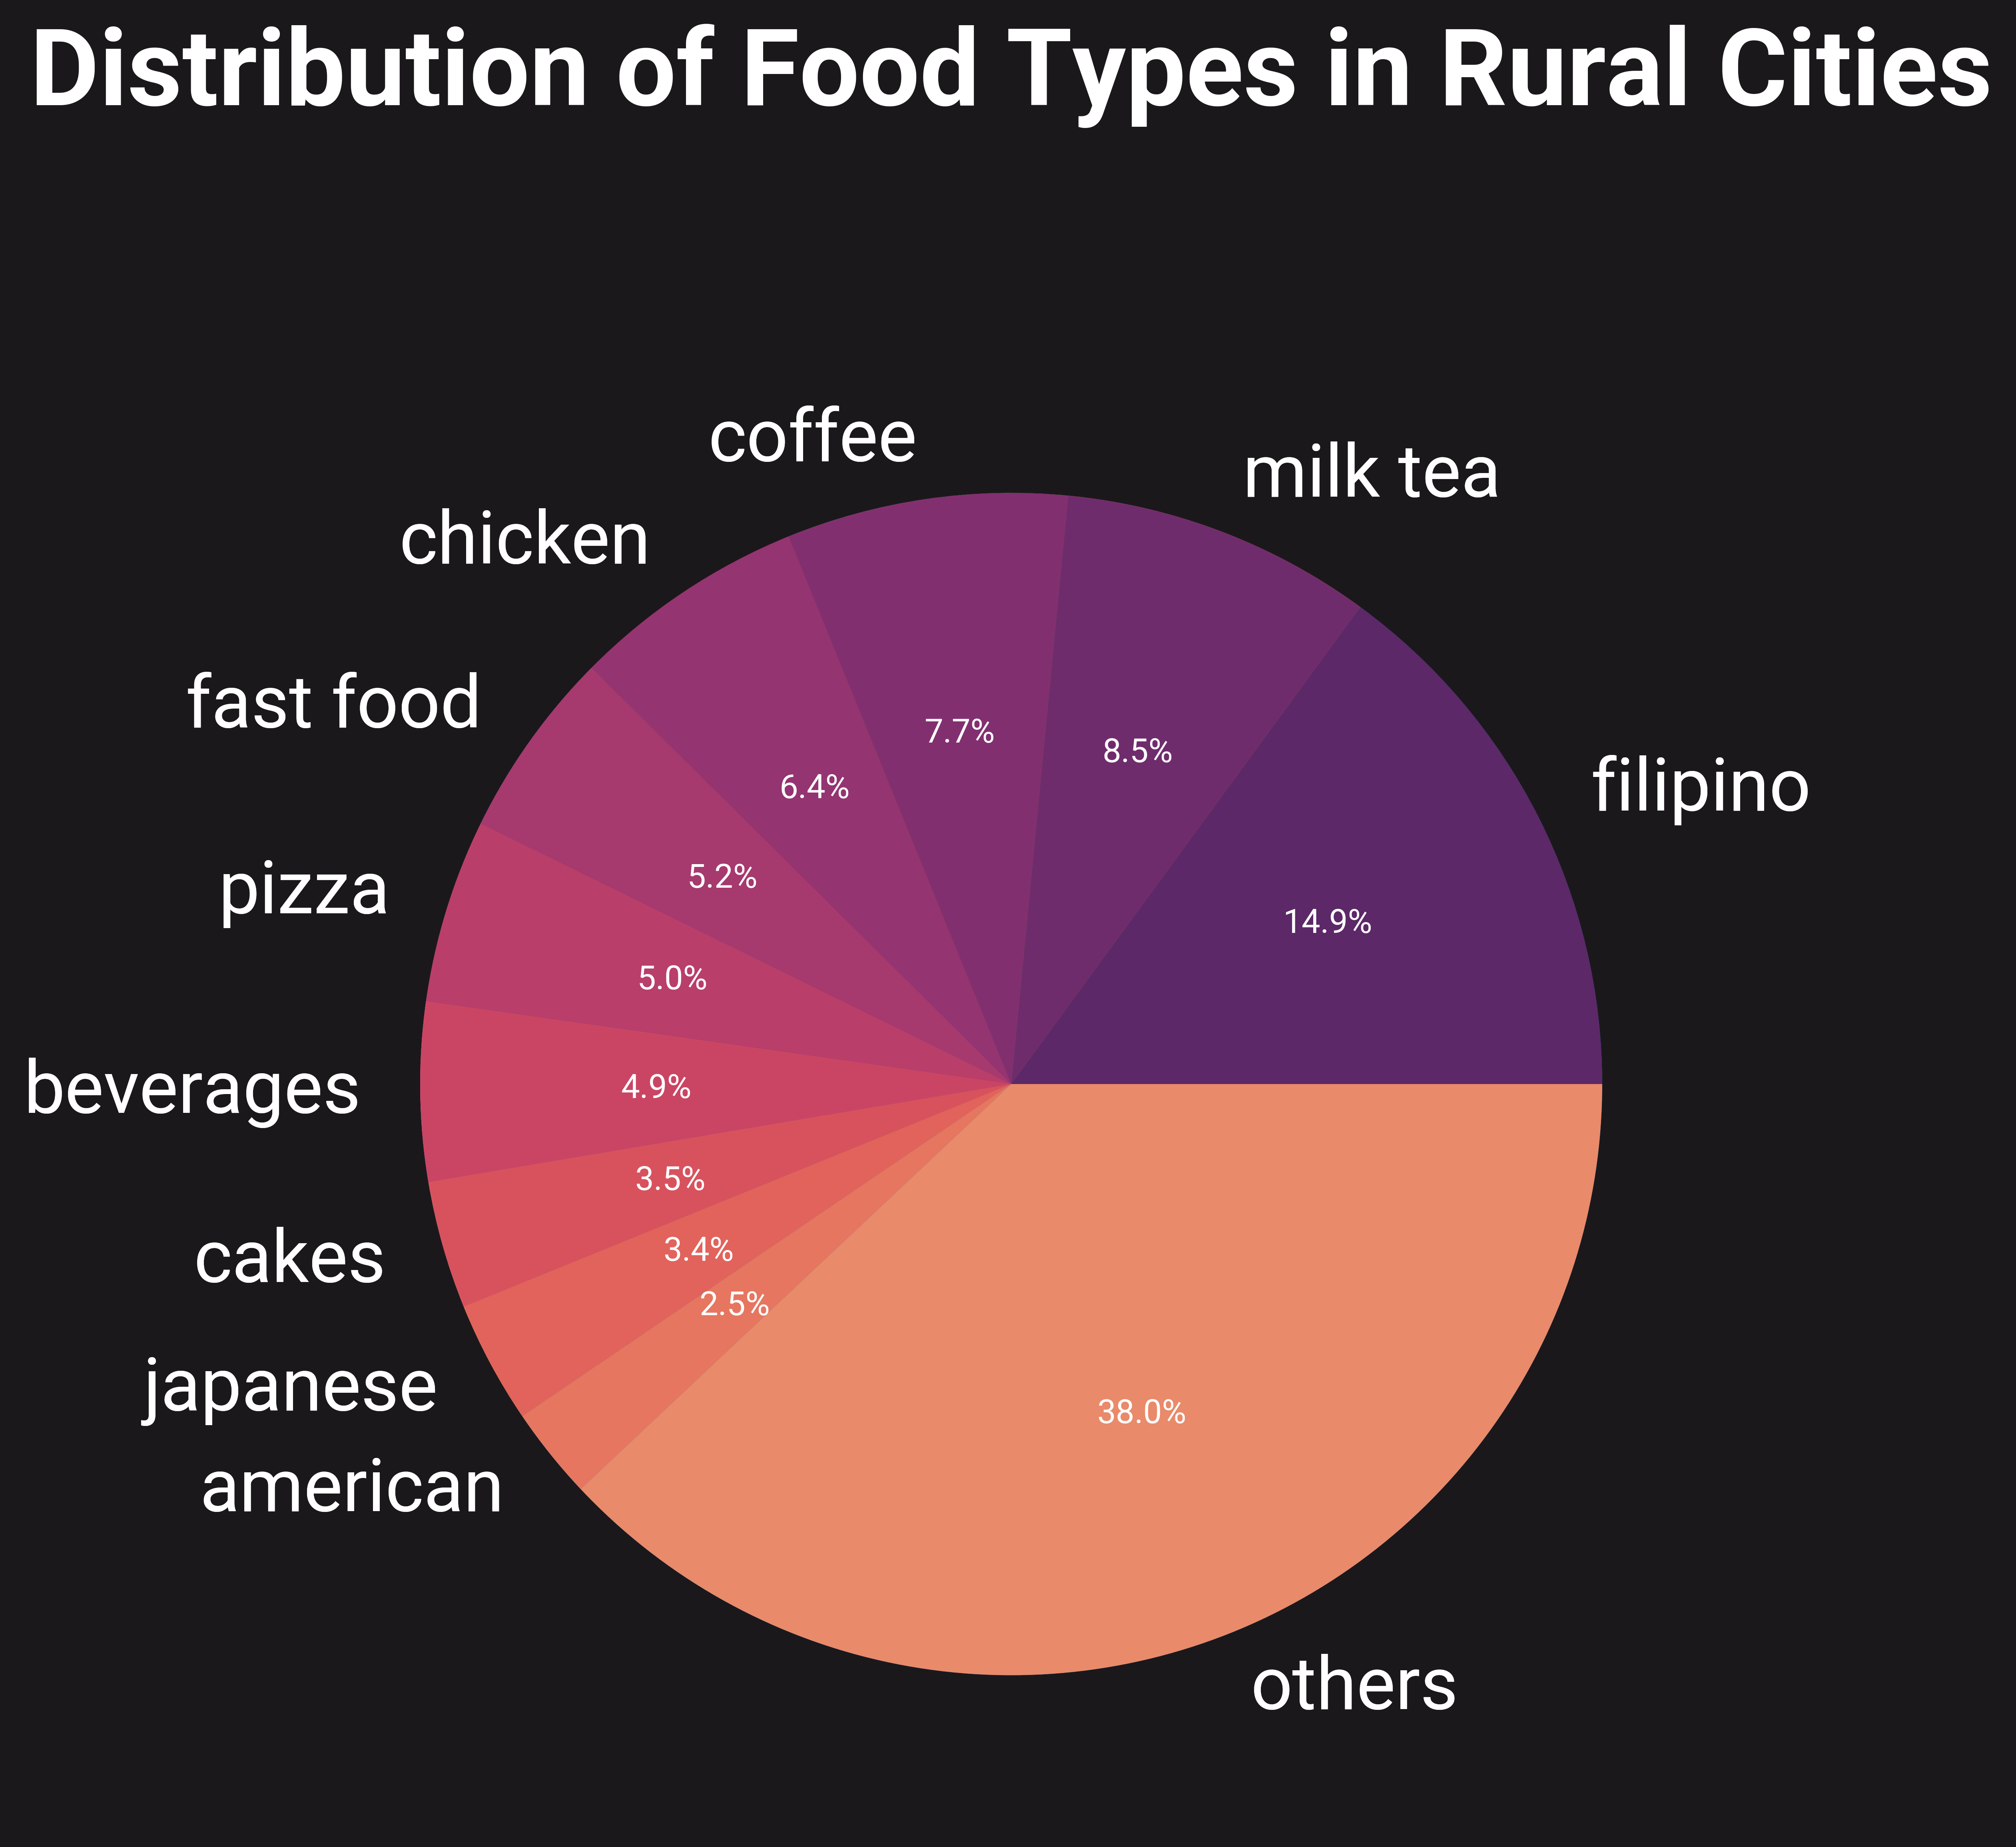

In [62]:
n = 0
num_counts = []
label_counts = []
others_counts = 0

for index, value in component_counts.items():
    if n<10:
        num_counts.append(value)
        label_counts.append(index)
    else:
        others_counts += value
    n+=1
num_counts.append(others_counts)
label_counts.append("others")

component_top10 = pd.Series(num_counts, label_counts)
component_top10.plot(kind='pie')
plt.pie(component_top10, colors=colors_grad, labels=label_counts, autopct='%1.1f%%')
plt.title(label="Distribution of Food Types in Rural Cities")
plt.show()